**Машинное обучение в экономике**

**Семинар 3. Деревья**

Установка библиотек

In [ ]:
# !python.exe -m pip install --upgrade pip
# !pip install numpy==1.26.4
# !pip install pandas # 1.5.3
#  !pip install scikit-learn
# !pip install openpyxl
# exit()

In [ ]:
# Подключим необходимые библиотеки
import numpy as np                                        # базовые операции с массивами
import pandas as pd                                       # базовые операции с датафреймами
from sklearn.naive_bayes import CategoricalNB             # наивный байесовский классификатор
from sklearn.model_selection import train_test_split      # разделение выборки на
                                                          # обучающую и тестовую
from sklearn.model_selection import cross_val_score       # кросс-валидация
from sklearn.model_selection import KFold                 # разбиение на фолды
import openpyxl                                           # работа с excel
import matplotlib.pyplot as plt                           # графики
from sklearn.metrics import confusion_matrix              # подсчет прогнозов
from sklearn.neighbors import KNeighborsClassifier        # метод ближайшие соседей
import sklearn
from sklearn.model_selection import GridSearchCV          # подбор гиперпараметров
from sklearn.model_selection import RandomizedSearchCV    # подбор гиперпараметров
import scipy                                              # распределения
from sklearn.metrics import RocCurveDisplay               # ROC-кривая
from sklearn import metrics                               # метрики точности
import itertools
from sklearn.ensemble import RandomForestClassifier       # случайный лес (классификация)
from sklearn.ensemble import RandomForestRegressor        # случайный лес (регрессия)
from sklearn import tree                                  # решающие деревья
from sklearn.inspection import permutation_importance     # перестановочная важность
from scipy.stats import rankdata                          # ранжирование элементов
from sklearn.ensemble import BaggingClassifier            # бэггинг
from copy import deepcopy                                 # копирование объектов
from sklearn.linear_model import LinearRegression         # копирование объектов

**Рассматриваемые методы**

1. Решающие деревья (dt - decision tree).
2. Регрессионные деревья (rt - regression tree).
3. Случайный лес (rf - random forest).

**Рассматриваемые техники**

1. Сравнение моделей по OOB ошибке
2. Измерение важности признаков с помощью случайного леса.




**Генерация данных** 🐰

In [ ]:
# Для воспроизводимости
np.random.seed(777)

# Число наблюдений
n = 5000

# Названия переменных
features_names = ["age", "income", "n_calls", "n_contacts",
                  "realoc", "educ", "churn", "spend"]

# Число признаков
m = len(features_names)

# Ковариации
sigma = np.empty(shape=(m, m), dtype = 'object')
sigma = pd.DataFrame(np.ones(shape=(m, m), dtype = 'object'),
                     index = features_names,
                     columns = features_names)

  # age
sigma.loc["age", "income"]         = 0.3
sigma.loc["age", "n_calls"]        = 0.1
sigma.loc["age", "n_contacts"]     = 0.1
sigma.loc["age", "realoc"]         = -0.3
sigma.loc["age", "educ"]           = 0.2
  # income
sigma.loc["income", "n_calls"]     = 0.3
sigma.loc["income", "n_contacts"]  = 0.2
sigma.loc["income", "realoc"]      = -0.3
sigma.loc["income", "educ"]        = 0.5
  # n_calls
sigma.loc["n_calls", "n_contacts"] = 0.5
sigma.loc["n_calls", "realoc"]     = 0.3
sigma.loc["n_calls", "educ"]       = -0.1
  # n_contacts
sigma.loc["n_contacts", "realoc"]  = -0.1
sigma.loc["n_contacts", "educ"]    = -0.1
  # realoc
sigma.loc["realoc", "educ"]        = -0.1

# Делаем нижнюю и верхнюю части ковариационной
# матрицы симметричными
for i in range(0, m):
  for j in range(0, i):
    sigma.iloc[i, j] = sigma.iloc[j, i]

# Генирируем данные из многомерного нормального распределения
df = np.random.multivariate_normal(mean = np.zeros(m), cov = sigma, size = n)
df = pd.DataFrame(df)
df.columns = features_names

# Приводим данные к реалистичному виду
  # age
df["age"] = pd.cut(df.loc[:, "age"],
                   bins = scipy.stats.norm.ppf
                     (
                     np.linspace(start = 0, stop = 1, num = 42),
                                 loc = 0, scale = 1
                     ),
                   labels = range(20, 61)
                  )
  # educ
df["educ"] = pd.cut(df.loc[:, "educ"],
                    bins = scipy.stats.norm.ppf
                      (
                        [0, 0.6, 0.9, 1],
                        loc = 0, scale = 1
                      ),
                      labels = range(1, 4)
                   )
  # realoc
df["realoc"] = pd.cut(df.loc[:, "realoc"],
                      bins = scipy.stats.norm.ppf
                             (
                               [0, 0.85, 1],
                               loc = 0, scale = 1
                             ),
                    labels = range(0, 2)
                    )
  # n_calls
df["n_calls"] = pd.cut(df.loc[:, "n_calls"],
                       bins = scipy.stats.norm.ppf(
                           np.concatenate
                             (
                               (
                                 [0],
                                 scipy.stats.poisson.cdf(k = range(0, 60),
                                                         mu = 30),
                                 [1]
                               )
                             ),
                           loc = 0, scale=  1),
                           labels = range(0, 61)
                        )
  # n_contacts
df["n_contacts"] = pd.cut(df.loc[:, "n_contacts"],
                          bins = scipy.stats.norm.ppf(
                           np.concatenate
                             (
                               (
                                 [0],
                                 scipy.stats.poisson.cdf(k = range(0, 40),
                                                         mu = 15),
                                 [1]
                               )
                             ),
                           loc = 0, scale=  1),
                           labels = range(0, 41)
                        )
  # income
df["income"] = np.round(
                         scipy.stats.expon.ppf
                           (
                             scipy.stats.norm.cdf(df["income"]), scale = 10
                           )
                       ) + 10

# Конвертируем данные в нужный формат
df = df.astype(float)

# Функция для стандартизации переменных
def std(x):
  val = (x - x.mean()) / x.std()
  return (val)

# Симулируем уход клиентов
churn_li = (
             -1 +                                                         \
             0.5 * std(df["age"]) - 0.1 * std(df["age"] ** 2) -           \
             0.9 * std(df["educ"]) +  std(0.5 * df["realoc"]) -           \
             0.5 * std(df["n_contacts"]) - 0.35 * std(df["n_calls"]) -    \
             0.45 * std(df["income"]) + 0.2 * std(df["income"] ** 2) +    \
             0.2 * std(df["age"] * df["educ"]) +                          \
             0.2 * std(df["educ"] * df["n_contacts"]) -                   \
             0.2 * std(df["n_contacts"] * df["n_calls"]) -                \
             0.4 * std(df["income"] * df["n_contacts"] * df["n_calls"])
          )
churn_prob  = scipy.stats.t.cdf(churn_li * 0.9, df = 5)
df["churn"] = np.random.binomial(n = 1, p = churn_prob, size = n)

# Симулируем затраты клиента
eps = np.abs(np.random.normal(size = n, loc = 2, scale = 1))
df["spend"] = 1 -                                                          \
              0.5 * std(df["age"]) + 0.1 * std(df["age"] ** 2) +           \
              0.9 * std(df["educ"]) -  std(0.5 * df["realoc"]) -           \
              0.5 * std(df["n_contacts"]) - 0.35 * std(df["n_calls"]) +    \
              0.45 * std(df["income"]) + 0.2 * std(df["income"] ** 2) -    \
              0.2 * std(df["age"] * df["educ"]) +                          \
              0.2 * std(df["educ"] * df["n_contacts"]) -                   \
              0.2 * std(df["n_contacts"] * df["n_calls"]) +                \
              0.4 * std(df["income"] * df["n_contacts"] * df["n_calls"]) + \
              eps
df["spend"] = np.round(np.abs(100 * df["spend"]), 0)

# Доля покупок
print({'churn': np.mean(df["churn"])})

# Корреляционная матрица
print(df.astype(float).corr(method = 'pearson'))

# Данные
print(df)

**Первичный анализ данных** 🐱

**Цели** ⭐

*   Изучить данные.  

Описание данных

*   `churn`      - уход клиента от мобильного оператора: 0 - не произошел, 1 - произошел.
*   `spend`      - расходы на звонки и прочие услуги оператора.
*   `age`        - возраст в годах.
*   `educ`       - уровень образовнания: 1 - среднее общее, 2 - среднее специальное, 3 - высшее.
*   `n_calls`    - число звонков за месяц.
*   `n_contacts` - количество контактов.
*   `income`     - доход в тысячах рублей.
*   `realoc`     - факт недавнего переезда.

In [ ]:
# Посмотрим первые несколько строк в данных
df.head(5)

In [ ]:
# Сохраним число наблюдений
n = df.index.size

In [ ]:
# Разделим целевую переменную и признаки
target   = df.loc[:, ['churn']]                            # целевая переменная
features = df.loc[:, df.columns.drop(['churn', 'spend'])]  # матрица признаков
target   = np.squeeze(target)                              # преобразуем из вектора столбца
                                                           # в одномерный массив

In [ ]:
# Разделим выборку на обучающую и тестовую
features_train, features_test, target_train, target_test = train_test_split(
    features, target, test_size = 0.2, random_state = 777)

# Сохраним число наблюдений обучающей и тестовой выборок
n_train = len(target_train)
n_test  = len(target_test)

# Вернем исходную сортировку индексов
features_train = features_train.reset_index(drop = True)
target_train   = target_train.reset_index(drop = True)
features_test  = features_test.reset_index(drop = True)
target_test    = target_test.reset_index(drop = True)

**Решающее дерево** 🐱

**Цели** ⭐

*   Обучить решающее дерево.
*   Спрогнозировать условные вероятности ухода клиентов.
*   Спрогнозировать уход клиентов.
*   Оценить точность прогнозов.


Техническое примечание ⚡

Функция `DecisionTreeClassifier()` возвращает объект, который можно использовать для обучения решающего дерева. Аргумент `max_depth` определяет (максимально допустимую) глубину данного дерева, а аргумент `critetion` отвечает за критерий, используемый для выбора признака при разбиении узла.

Подробней о функции `DecisionTreeClassifier()` можно прочитать в [документации](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html).

In [ ]:
# Обучим решающее дерево
dt = tree.DecisionTreeClassifier(max_depth = 3, criterion = 'entropy')
dt.fit(features_train, target_train)

Техническое примечание ⚡

Аргумент `features_names` позволяет отобразить имена признаков на графике. Обычно, в качестве этих имен удобно взять названия столбцов матрицы признаков, использовавшеся для обучения, в данном случае `features.columns`.

Подробней о функции `plot_tree()` можно прочитать в [документации](https://scikit-learn.org/stable/modules/generated/sklearn.tree.plot_tree.html).

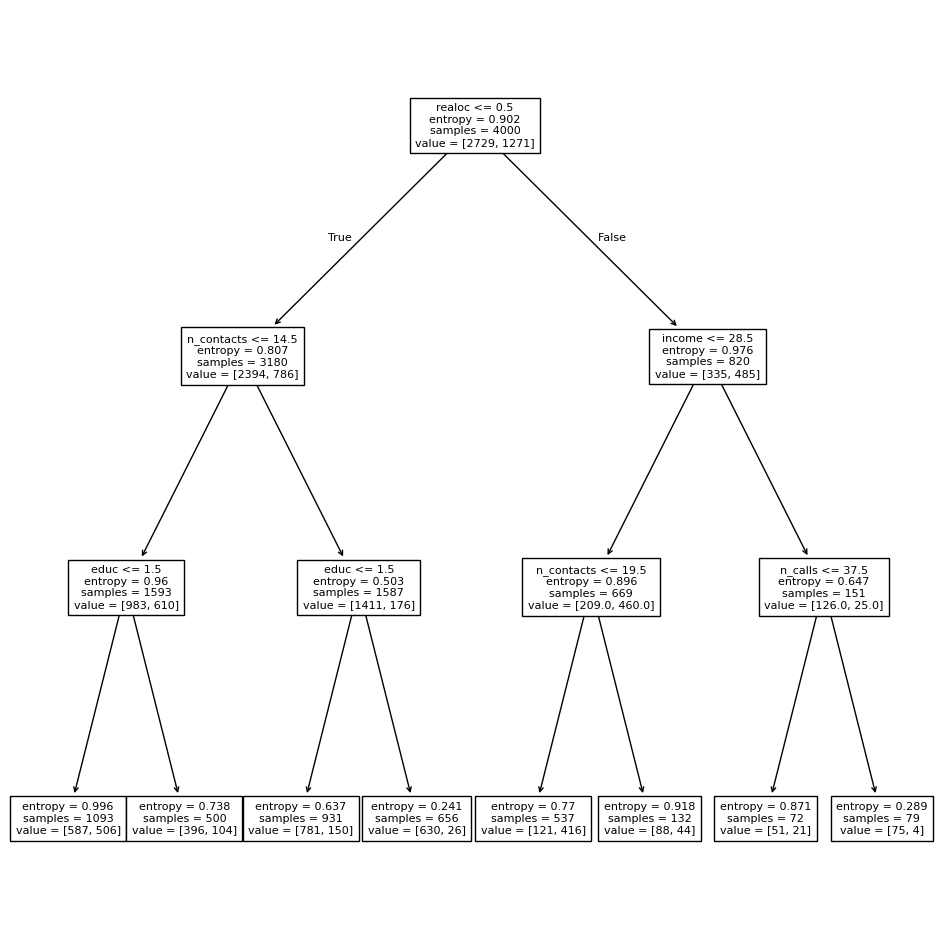

In [ ]:
# Визуализируем полученный результат
plt.figure(figsize=(12, 12))
tree.plot_tree(dt, feature_names = features_train.columns, fontsize = 8)
plt.show()

Оценим условные вероятности ухода клиентов:

$$p_{i} = P(\text{Churn} = 1 | X_{i}) = P(\text{Churn} = 1 |\text{Age} = \text{Age}_{i}, ..., \text{Realoc} = \text{Realoc}_{i})$$

In [ ]:
# Оцениваем условные вероятности
prob_dt = dt.predict_proba(features_train)
print(prob_dt[0:10:, 0])                   # оценки P(Y = 0 | X = x)
print(prob_dt[0:10:, 1])                   # оценки P(Y = 1 | X = x)

Получим прогнозные значения:

$$\widehat{\text{Churn}}_{i} = \begin{cases}1\text{, если }\hat{p}_{i}\geq 0.5\\0\text{, в противном случае}\end{cases}$$

In [ ]:
# Прогнозы
prediction_dt = dt.predict(features_train)       # I(P(Y = 1 | X = x) > 0.5)

Оценим точность прогнозов:

$$\text{ACC} = \frac{1}{n}\sum\limits_{i=1}^{n}I(\text{Churn}_{i} = \widehat{\text{Churn}}_{i})$$

In [ ]:
# Оценим точность на обучающей выборке
ACC_train_dt = dt.score(features_train, target_train)
print(ACC_train_dt)

**Проблема переобучения решающих деревьев** 🐱

**Цели** ⭐

*   Проиллюстрировать проблему переобучения слишком глубоких решающих деревьев: хорошая точность на обучающей выборке, но низкая - на тестовой.


In [ ]:
# Сделаем максимальную глубину дерева достаточно большой
dt2 = tree.DecisionTreeClassifier(max_depth = 20, criterion = 'entropy')
dt2.fit(features_train, target_train)

In [ ]:
# Оценим точность на обучающей выборке
ACC_train_dt2 = dt2.score(features_train, target_train)

In [ ]:
# Сравним точность внутривыборочного прогноза с деревом,
# обладающим меньшей максимальной глубиной
print(pd.DataFrame(data    = [ACC_train_dt, ACC_train_dt2],
                   index   = ['Неглубокое дерево', 'Глубокое дерево'],
                   columns = ['ACC']))

In [ ]:
# Сопоставим точность вневыборочно прогноза на тестовой выборке
ACC_test_dt = dt.score(features_test, target_test)
ACC_test_dt2 = dt2.score(features_test, target_test)
print(pd.DataFrame(data    = [ACC_test_dt, ACC_test_dt2],
                   index   = ['Неглубокое дерево', 'Глубокое дерево'],
                   columns = ['ACC тест']))

In [ ]:
# Сопоставим точность вневыборочно прогноза с помощью кросс-валидации
ACC_CV_dt  = np.mean(cross_val_score(dt, features_train, target_train, cv = 5))
ACC_CV_dt2 = np.mean(cross_val_score(dt2, features_train, target_train, cv = 5))
print(pd.DataFrame(data    = [ACC_CV_dt, ACC_CV_dt2],
                   index   = ['Неглубокое дерево', 'Глубокое дерево'],
                   columns = ['ACC-CV']))

                   ACC-CV
Неглубокое дерево  0.7475
Глубокое дерево    0.7245


**Подбор оптимальной глубины дерева** 🐱

**Цели** ⭐

*   Подобрать оптимальную глубину решающего дерева с помощью кросс-валидации.


In [ ]:
# Перебираемые значения гиперпараметров
hyperparameters = {'max_depth': range(0, 20)}

# Перебор гиперпараметров с помощью кросс-валидации
GSCV_dt = GridSearchCV(estimator  = dt,                # модель
                       param_grid = hyperparameters,   # перебираемые гиперпараметры
                       scoring    = "accuracy",        # метрика качества модели
                       cv         = 5)                 # число фолдов в кросс-валидации
GSCV_dt.fit(features_train, target_train)              # подбор гиперпараметров
                                                       # на конкретных данных

# Достанем гиперпараметры, соответствующие лучшей модели
hyperparameters_best = GSCV_dt.best_params_

# Обучим модель с лучшими параметрами
dt3 = tree.DecisionTreeClassifier(max_depth = hyperparameters_best["max_depth"],
                                  criterion = 'entropy')
dt3.fit(features_train, target_train)

# Посмотрим на оптимальную глубину дерева
print(hyperparameters_best)

In [ ]:
# Сравним точность на тестовой выборке
ACC_test_dt3 = dt3.score(features_test, target_test)
print(pd.DataFrame(data    = [ACC_test_dt, ACC_test_dt2, ACC_test_dt3],
                   index   = ['Неглубокое дерево', 'Глубокое дерево',
                              'Дерево оптимальной глубины'],
                   columns = ['ACC тест']))

**Случайный лес** 🐱

**Цели** ⭐

*   Обучить случайный лес.
*   Спрогнозировать условные вероятности ухода клиентов.
*   Спрогнозировать уход клиентов.
*   Оценить точность прогнозов случайного леса и сопоставить ее с точностью прогнозов решающих деревьев.


Техническое примечание ⚡

Функция `RandomForestClassifier()` возвращает объект, который можно использовать для обучения случайного леса.

Основные аргументы:

*   `max_depth` - максимальная глубина решающего дерева.
*   `max_features` - количество случайно выбираем на каждом шаге признаков, рассматриваемых в качестве кандидатов при разбиении очередного узла (вершины). Специальное значение `'sqrt'` позволяет использовать квадратный корень из числа всех признаков.
*   `max_samples` - число бутстрап итераций, то есть решающих деревьев, используемых в случайном лесе.

Подробней о функции `RandomForestClassifier()` можно прочитать в [документации](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html).

**Важно** - результаты случайного леса могут каждый раз различаться, поскольку наблюдения и регрессоры, используемые для разбиения очередного узла в дереве, отбираются случайным образом. Во избежания различий можно, например, установить зачение в аргументе `random_state`.

In [ ]:
# Обучим случайный лес
rf = RandomForestClassifier(max_depth    = 12,         # максимальная глубина деревьев
                            max_features = "sqrt",     # число случайно выбираемых при
                                                       # каждом разбиении признаков
                            max_samples  = 500,        # число бутстрап итераций
                            random_state = 777,        # для вопроизводимости
                            criterion    = 'entropy')  # критерий выбора признаков
                                                       # при разбиении узлов
rf.fit(features_train, target_train)

In [ ]:
# Оценим условные вероятности
prob_rf = rf.predict_proba(features_train)
print(prob_rf[0:10:, 0])                            # оценки P(Y = 0 | X = x)
print(prob_rf[0:10:, 1])                            # оценки P(Y = 1 | X = x)

In [ ]:
# Прогнозы
prediction_rf = rf.predict(features_train)          # I(P(Y = 1 | X = x) > 0.5)

In [ ]:
# Оценим точность внутри выборки
ACC_train_rf = rf.score(features_train, target_train)
print(pd.DataFrame(data    = [ACC_train_dt, ACC_train_dt2, ACC_train_rf],
                   index   = ['Неглубокое дерево', 'Глубокое дерево',
                              'Случайный лес'],
                   columns = ['ACC']))

In [ ]:
# Сопоставим точность на тестовой выборке
ACC_test_rf = rf.score(features_test, target_test)
print(pd.DataFrame(data    = [ACC_test_dt, ACC_test_dt2, ACC_test_dt3, ACC_test_rf],
                   index   = ['Неглубокое дерево', 'Глубокое дерево',
                              'Оптимальное дерево', 'Случайный лес'],
                   columns = ['ACC тест']))

**Ошибка неотобранных элементов** 🐱

**Цели** ⭐

*   Сравнить между собой два случайных леса при помощи ошибки неотобранных элементов (OOB error).


Алгоритм расчета OOB ошибки:

1.   Модель оценивается с помощью ансамбля, например, случайного леса.
2.   Для каждого наблюдения строится прогноз с использованием лишь тех моделей ансамбля, которые не использовали это наблюдение для обучения.
3.   Считается средняя ошибка прогноза этих наблюдений.



Техническое примечание ⚡

Чтобы изменить параметры модели не обязательно создавать новый объект и заново прописывать значения аргументов. Достаточно изменить своства данного объекта.

Например, мы изначально не указывали необходимость расчета OOB ошибки в `rf` модели. Однако, указав, что `rf.oob_score = True` и заново обучив модель `rf.fit(features, target)` мы можем получить соответствующее значение, достав обратную ему величину из свойства `rf.oob_score_`.

**Важно** - `rf.oob_score_` отражает не OOB ошибку, а обратное ей среднее число верно классифицированных неотобранных объектов. Поэтому, для расчета OOB ошибки можно использовать `1 - rf.oob_score_`.

In [ ]:
# Ошибка неотобранных элементов (OOB error)
rf.oob_score = True                         # укажем необходимость подсчета OOB
rf.fit(features_train, target_train)        # обучим модель рассчитав OOB
oob_rf = 1 - rf.oob_score_                  # значение OOB

In [ ]:
# Повторим оценивание с другим числом признаков
rf2              = deepcopy(rf)
rf2.max_features = 3                        # число случайно выбираемых при
                                            # каждом разбиении узла признаков
rf2.fit(features_train, target_train)       # обучаем новую модель
oob_rf2 = 1 - rf2.oob_score_                # значение OOB

# Сравним OOB моделей (чем меньше, тем лучше)
print(pd.DataFrame(data    = [oob_rf, oob_rf2],
                   index   = ['Случайный лес 1', 'Случайный лес 2'],
                   columns = ['OOB']))

**Преимущество OOB ошибки** - обычно быстрее, чем кросс-валидация, поскольку не нужно многократно обучать модель.

**Недостаток OOB ошибки** - нельзя использовать за пределами ансамблевых методов, что осложняет сопоставление их результатов с неансамблевыми методами.

In [ ]:
# Сравним результаты кросс-валидации (чем больше, тем лучше)
ACC_CV_rf  = np.mean(cross_val_score(rf, features_train, target_train, cv = 5))
ACC_CV_rf2 = np.mean(cross_val_score(rf2, features_train, target_train, cv = 5))
print(pd.DataFrame(data    = [ACC_CV_rf, ACC_CV_rf2],
                   index   = ['Случайный лес 1', 'Случайный лес 2'],
                   columns = ['ACC-CV']))

**Расчет важности признаков** 🐱

**Цели** ⭐

*   Оценить важность признаков с помощью случайного леса используя два подхода.
*   Обучить решающее дерево используя лишь несколько наиболее важных признаков и оценить точность модели.

In [ ]:
# Рассмотрим важность признаков на
# основании снижения неопределенности
importances = pd.Series(rf.feature_importances_, index = features.columns)
importances.plot.bar()
plt.show()

Для избежания подгонки под тестовые данные при расчете перестановочной важности лучше использовать валидационную выборку. Однако, для краткости в данном случае мы будем ориентироваться на тестовую выборку.

In [ ]:
# Рассмотрим важность регрессоров на
# основании перестановок
importances2 = permutation_importance(estimator = rf,
                                      X = features_test,
                                      y = target_test,
                                      scoring = "accuracy")
importances2 = pd.Series(importances2["importances_mean"],
                         index = features_train.columns)
print(importances2)

In [ ]:
# Для удобства отсортируем признаки в порядке важности
importances2 = importances2.sort_values(ascending = False)
print(importances2)

В целом деревья ограниченной глубины устойчивы к включению в них неважных признаков, поскольку, как правило, эти признаки не будут участвовать в разбиении узлов. Однако, для простоты рассмотрим изменение точности прогнозов случайного леса при включении в него лишь наиболее важных признаков.

In [ ]:
# Обучим случайный лес с тремя наиболее важными признаками
rf3 = deepcopy(rf)
n_important = 3
rf3.fit(features_train.loc[:, importances2.index[range(0, 3)]], target_train)

In [ ]:
# Сравним результаты на тестовой выборке
ACC_test_rf  = rf.score(features_test, target_test)
ACC_test_rf2 = rf2.score(features_test, target_test)
ACC_test_rf3 = rf3.score(features_test.loc[:, importances2.index[range(0, 3)]],
                         target_test)
print(pd.DataFrame(data    = [ACC_test_rf, ACC_test_rf2, ACC_test_rf3],
                   index   = ['Случайный лес 1',
                              'Случайный лес 2',
                              'Случайный лес 3'],
                   columns = ['ACC тест']))

**Бэггинг с использованием метода ближайших соседей (метод случайных соседей)** 🐱

**Цели** ⭐

*   Использовать бэггинг для обучения ансамбля из методов ближайшего соседа.
*   Сравнить точность и OOB ошибку "метода случайных соседей" и случайного леса.


Техническое примечание ⚡

Функция `BaggingClassifier()` возвращает объект, который можно использовать для обучения ансамбля с помощью бэггинга, взяв за основу один из методов машинного обучения.

Основные аргументы:

*   `estimator` - методы, использующийся в ансамбле, например, решающее дерево или метод ближайших соседей.
*   `max_features` - количество признаков, случайным образом отбираемых при обучении методов в ансамбле.
*   `n_estimators` - число бутстрап итераций, то есть решающих деревьев, используемых в случайном лесе.
*   `oob_score` - если `True`, то рассчитывается OOB ошибка.

Подробней о функции `BaggingClassifier()` можно прочитать в [документации](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.BaggingClassifier.html#sklearn.ensemble.BaggingClassifier).

In [ ]:
# Создадим ансамбль используя бэггинг,
# взяв за основу метод ближайших соседей
knn   = KNeighborsClassifier(n_neighbors = 3)
knn_b = BaggingClassifier(estimator    = knn,
                          n_estimators = 100,
                          max_features = int(np.sqrt(features_train.shape[1])),
                          oob_score    = True)
knn_b.fit(features_train, target_train)

In [ ]:
# Сравним результаты со случайным лесом с помощью кросс-валидации
ACC_CV_knn_b = np.mean(cross_val_score(knn_b, features_train,
                                       target_train, cv = 5))
print(pd.DataFrame(data    = [ACC_CV_rf, ACC_CV_knn_b],
                   index   = ['Случайный лес', 'Случайные соседи'],
                   columns = ['ACC-CV']))

In [ ]:
# Сопоставим результаты со случайным лесом с помощью OOB ошибки
oob_knn_b = 1 - knn_b.oob_score_
print(pd.DataFrame(data    = [oob_rf, oob_knn_b],
                   index   = ['Случайный лес', 'Случайные соседи'],
                   columns = ['OOB']))

**Регрессионные деревья** 🐱

**Цели** ⭐

*   Обучить регрессионное дерево, случайный лес и линейную регрессию для прогнозирования расходов пользователей.
*   Сравнить точность прогнозов моделей.


In [ ]:
# Разделим целевую переменную и признаки
target2   = df.loc[:, ['spend']]                            # целевая переменная
features2 = df.loc[:, df.columns.drop(['churn', 'spend'])]  # матрица признаков
target2   = np.squeeze(target2)                             # преобразуем из вектора столбца
                                                            # в одномерный массив

In [ ]:
# Разделим выборку на обучающую и тестовую
features2_train, features2_test, target2_train, target2_test = train_test_split(
    features2, target2, test_size = 0.2, random_state = 777)

# Сохраним число наблюдений обучающей и тестовой выборок
n_train = len(target2_train)
n_test  = len(target2_test)

# Вернем исходную сортировку индексов
features2_train = features2_train.reset_index(drop = True)
target2_train   = target2_train.reset_index(drop = True)
features2_test  = features2_test.reset_index(drop = True)
target2_test    = target2_test.reset_index(drop = True)

In [ ]:
# Обучим регрессионное дерево
rt = tree.DecisionTreeRegressor(max_depth = 10, criterion = 'squared_error')
rt.fit(features2_train, target2_train)

In [ ]:
# Визуализируем полученный результат, для наглядности
# и быстроты ограничив максимальную глубину на картинке
plt.figure(figsize = (12, 12))
tree.plot_tree(rt, feature_names = features_train.columns,
               fontsize = 8, max_depth = 2)
plt.show()

In [ ]:
# Обучим случайный лес из регрессионных деревьев
rfr = RandomForestRegressor(max_depth    = 10,              # максимальная глубина деревьев
                            max_features = "sqrt",          # число случайно выбираемых на
                                                            # каждой итерации признаков
                            max_samples  = 500,             # число бутстрап итераций
                            random_state = 777,             # для воспроизводимости
                            criterion    = 'squared_error') # критерий выбора признаков
                                                            # при разбиении узлов
rfr.fit(features2_train, target2_train)

$$\text{МНК: }\hat{Y}_{i} = \hat{\beta}_{0} + \hat{\beta}_{1}X_{i1} + ... + \hat{\beta}_{m}X_{im}$$

In [ ]:
# Оценим МНК регрессию
ls = LinearRegression()
ls.fit(features2_train, target2_train)

In [ ]:
# Достанем прогнозы моделей
predict_test_rt  = rt.predict(features2_test)
predict_test_rfr = rfr.predict(features2_test)
predict_test_ls  = ls.predict(features2_test)

$$\text{MSE} = \frac{1}{n}\sum\limits_{i=1}^{n} \left(\hat{Y}_{i} - Y_{i}\right)^2$$

In [ ]:
# Сравним MSE моделей на тестовой выборке
MSE_test_rt  = sklearn.metrics.mean_squared_error(target2_test, predict_test_rt)
MSE_test_rfr = sklearn.metrics.mean_squared_error(target2_test, predict_test_rfr)
MSE_test_ls  = sklearn.metrics.mean_squared_error(target2_test, predict_test_ls)
print(pd.DataFrame(data    = [MSE_test_rt, MSE_test_rfr, MSE_test_ls],
                   index   = ['Регрессионное дерево', 'Случайный лес', 'МНК'],
                   columns = ['MSE тест']))